<a href="https://colab.research.google.com/github/Fedyatch/DB2025/blob/main/Practic1_Chausov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Настройка окружения и загрузка данных

In [13]:
import torch
import torchvision

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"CUDA доступна: {torch.cuda.is_available()}")

if torch.cuda.is_available():
  print(f"GPU : {torch.cuda.get_device_name(0)}")

# Устройство для вычислений: GPU если есть, иначе CPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nИспользуемое устройство: {DEVICE}")

# Если GPU не найден — Runtime → Change runtime type → GPU (T4)

PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
CUDA доступна: True
GPU : Tesla T4

Используемое устройство: cuda


In [14]:
# Устанавливаем Kaggle API для скачивания датасета
!pip install -q kaggle

### Загрузка датасета RVF10K с Kaggle

In [15]:
# Загрузка kaggle.json через интерфейс Colab
from google.colab import files
files.upload()  # Загрузите файл kaggle.json

# Настраиваем Kaggle API и скачиваем датасет
import os
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Скачиваем RVF10K (~80 МБ, быстро)
!kaggle datasets download -d sachchitkunichetty/rvf10k -p /content/data --unzip
print("\nДатасет загружен!")

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/sachchitkunichetty/rvf10k
License(s): CC-BY-NC-SA-4.0
100% 273M/273M [00:07<00:00, 39.4MB/s]


Датасет загружен!


In [16]:
# Проверяем структуру данных и автоматически находим пути
import os
from pathlib import Path

# Показываем структуру папок
!find /content/data -type d | sort

# Автоматический поиск train и test директорий
def find_data_dirs(base='/content/data'):
    """Ищет папки train/test (или valid) в любой вложенности."""
    train_dir = test_dir = None
    for root, dirs, files in os.walk(base):
        for d in dirs:
            dl = d.lower()
            full = os.path.join(root, d)
            # Проверяем что внутри есть подпапки с классами
            subdirs = [s for s in os.listdir(full) if os.path.isdir(os.path.join(full, s))]
            if len(subdirs) >= 2:  # минимум 2 класса
                if dl in ('train', 'training'):
                    train_dir = full
                elif dl in ('test', 'testing', 'valid', 'validation', 'val'):
                    test_dir = full
    return train_dir, test_dir

train_path, test_path = find_data_dirs()

if train_path and test_path:
    TRAIN_DIR = Path(train_path)
    TEST_DIR = Path(test_path)
    print(f"\n Train: {TRAIN_DIR}")
    print(f" Test:  {TEST_DIR}")
    print(f"  Train classes: {sorted(os.listdir(TRAIN_DIR))}")
    print(f"  Test classes:  {sorted(os.listdir(TEST_DIR))}")
else:
    print(" Не удалось найти train/test папки!")
    print("Проверь структуру выше и задай вручную:")
    print("  TRAIN_DIR = Path('/content/data/...')")
    print("  TEST_DIR = Path('/content/data/...')")

/content/data
/content/data/rvf10k
/content/data/rvf10k/train
/content/data/rvf10k/train/fake
/content/data/rvf10k/train/real
/content/data/rvf10k/valid
/content/data/rvf10k/valid/fake
/content/data/rvf10k/valid/real

 Train: /content/data/rvf10k/train
 Test:  /content/data/rvf10k/valid
  Train classes: ['fake', 'real']
  Test classes:  ['fake', 'real']


## 2. Разведочный анализ данных (EDA)

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Подсчитываем количество изображений в каждом классе
for split_name, split_dir in [('Train', TRAIN_DIR), ('Test', TEST_DIR)]:
    print(f'{split_name} набор:')

    for cls in sorted([d.name for d in split_dir.iterdir() if d.is_dir()]):
        count = len(list((split_dir / cls).glob('*')))
        print(f'  {cls}: {count} изображений')

    print()  # пустая строка между split'ами

Train набор:
  fake: 3500 изображений
  real: 3500 изображений

Test набор:
  fake: 1500 изображений
  real: 1500 изображений



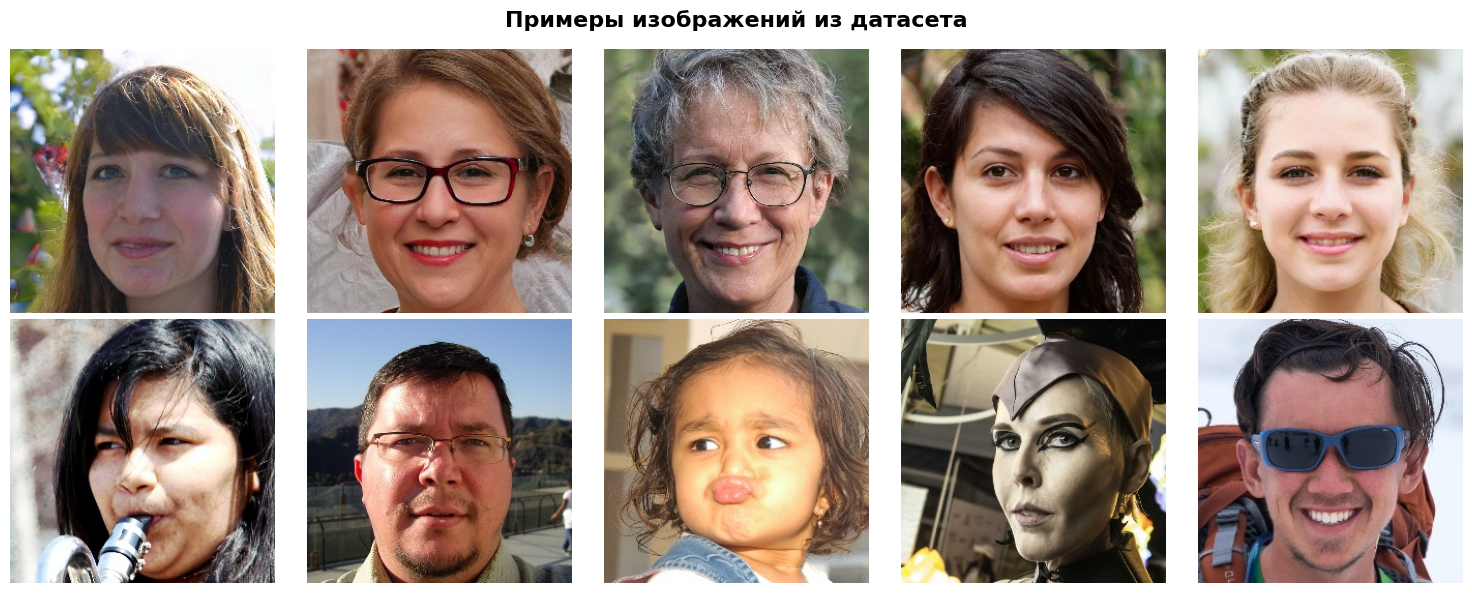

In [18]:
# Визуализируем примеры из каждого класса
class_dirs = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Примеры изображений из датасета', fontsize=16, fontweight='bold')

for row, cls in enumerate(class_dirs):
    # Берём первые 5 изображений класса
    images = list((TRAIN_DIR / cls).glob('*'))[:5]

    for col, img_path in enumerate(images):
        img = Image.open(img_path)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')

        # Подпись класса только для первого столбца
        if col == 0:
            axes[row, col].set_ylabel(
                cls, fontsize=14, fontweight='bold',
                rotation=0, labelpad=50, ha='right'
            )

plt.tight_layout()
plt.savefig('/content/examples.png', dpi=100, bbox_inches='tight')
plt.show()

Соотношение классов: 1.000 — сбалансирован!


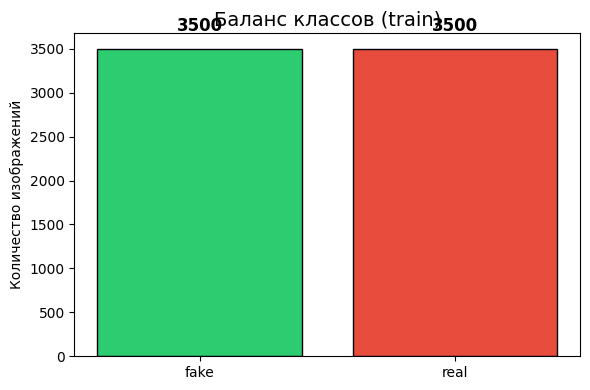

In [19]:
# Баланс классов
class_dirs = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
counts = [len(list((TRAIN_DIR / cls).glob('*'))) for cls in class_dirs]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(class_dirs, counts, color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax.set_title('Баланс классов (train)', fontsize=14)
ax.set_ylabel('Количество изображений')

# Добавляем значения на столбцы
for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f'{count}',
        ha='center', fontsize=12, fontweight='bold'
    )

# Оценка баланса
ratio = min(counts) / max(counts)
balance_status = 'сбалансирован' if ratio > 0.8 else 'дисбаланс'
print(f'Соотношение классов: {ratio:.3f} — {balance_status}!')

plt.tight_layout()
plt.savefig('/content/class_balance.png', dpi=100, bbox_inches='tight')
plt.show()

In [20]:
# Проверяем размеры изображений (выборка по 10 из каждого класса)
sample_paths = []
for cls in class_dirs:
    sample_paths.extend(list((TRAIN_DIR / cls).glob('*'))[:10])

sizes = [Image.open(p).size for p in sample_paths]

print(f'Проверено изображений: {len(sizes)}')
print(f'Уникальные размеры: {set(sizes)}')

# Если размеры различаются — выводим статистику
if len(set(sizes)) > 1:
    widths, heights = zip(*sizes)
    print(f'\nСтатистика размеров:')
    print(f'  Ширина:  мин={min(widths)}, макс={max(widths)}, медиана={np.median(widths):.0f}')
    print(f'  Высота:  мин={min(heights)}, макс={max(heights)}, медиана={np.median(heights):.0f}')

Проверено изображений: 20
Уникальные размеры: {(256, 256)}


## 3. Предобработка и аугментация

**train_transform** — с аугментацией (flip, rotation, color jitter) для борьбы с переобучением.

**test_transform** — только resize и нормализация, без аугментации.


In [21]:
import torch
import torch.nn as nn
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ГИПЕРПАРАМЕТРЫ

IMG_SIZE    = 224          # Стандартный вход для моделей torchvision
BATCH_SIZE  = 32           # Размер батча
NUM_WORKERS = 2            # Фоновые процессы загрузки данных
SEED        = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

# Нормализация ImageNet (обязательна для предобученных моделей)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Аугментация для обучающей выборки
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),               # Resize до 224x224
    transforms.RandomHorizontalFlip(p=0.5),                # Горизонтальный переворот
    transforms.RandomRotation(degrees=10),                 # Поворот +/-10 градусов
    transforms.ColorJitter(brightness=0.1, contrast=0.1),  # Яркость/контраст
    transforms.ToTensor(),                                 # PIL -> Tensor [0, 1]
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)      # Нормализация ImageNet
])

# Для теста - только resize и нормализация
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

print("Трансформации определены")

Трансформации определены


In [22]:
# Создаём датасеты через ImageFolder
# ImageFolder присваивает метки по именам папок (алфавитный порядок)
train_dataset = datasets.ImageFolder(root=str(TRAIN_DIR), transform=train_transform)
test_dataset  = datasets.ImageFolder(root=str(TEST_DIR),  transform=test_transform)

# DataLoader - выдаёт батчи данных
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# Названия классов и проверка
class_names = train_dataset.classes
num_classes = len(class_names)

print(f"Маппинг классов: {train_dataset.class_to_idx}")
print(f"Классы: {class_names}")
print(f"\nTrain: {len(train_dataset)} изображений, {len(train_loader)} батчей")
print(f"Test:  {len(test_dataset)} изображений, {len(test_loader)} батчей")

if train_dataset.classes != test_dataset.classes:
    print("ВНИМАНИЕ: классы в train и test не совпадают!")
else:
    print("Классы в train и test совпадают")

Маппинг классов: {'fake': 0, 'real': 1}
Классы: ['fake', 'real']

Train: 7000 изображений, 219 батчей
Test:  3000 изображений, 94 батчей
Классы в train и test совпадают


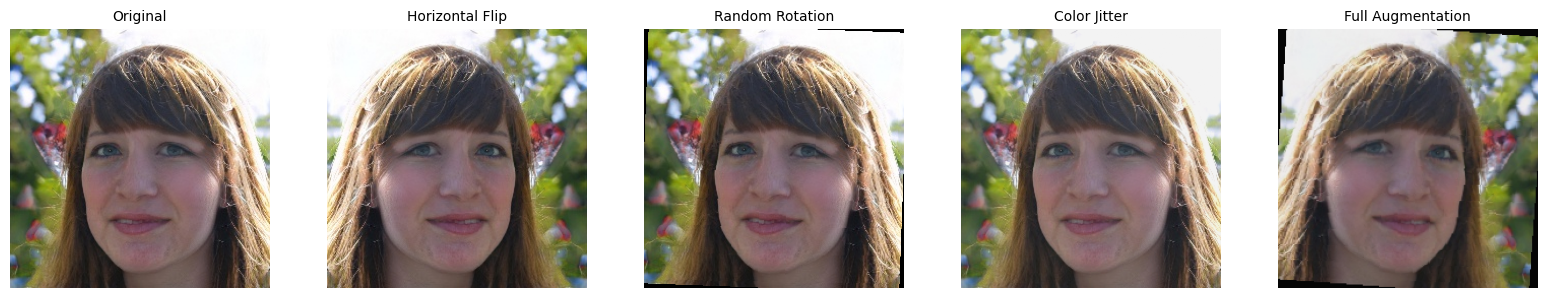

augmentations_preview.png saved


In [24]:
# Визуализация аугментаций на примере изображения из датасета
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from pathlib import Path

import torch

def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Обратная нормализация ImageNet для корректного отображения изображений."""
    t = tensor.clone()
    for ch, m, s in zip(t, mean, std):
        ch.mul_(s).add_(m)
    return torch.clamp(t, 0, 1)

# Берём случайное изображение из первого класса train-набора
sample_path = list((Path(TRAIN_DIR) / class_dirs[0]).glob('*'))[0]
raw_img = Image.open(sample_path)

# Список трансформаций для сравнения
transforms_list = [
    ("Original", transforms.ToTensor()),
    ("Horizontal Flip", transforms.Compose([
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor()
    ])),
    ("Random Rotation", transforms.Compose([
        transforms.RandomRotation(15),
        transforms.ToTensor()
    ])),
    ("Color Jitter", transforms.Compose([
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor()
    ])),
    ("Full Augmentation", train_transform)
]

plt.figure(figsize=(16, 3))
for i, (name, transform) in enumerate(transforms_list):
    # Применяем трансформацию к PIL-изображению
    tensor_img = transform(raw_img)

    # Денормализуем только полный пайплайн (он содержит Normalize)
    if name == "Full Augmentation":
        display_img = denormalize(tensor_img)
    else:
        display_img = tensor_img

    plt.subplot(1, len(transforms_list), i + 1)
    plt.imshow(display_img.permute(1, 2, 0).numpy().clip(0, 1))
    plt.title(name, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.savefig('/content/augmentations_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print("augmentations_preview.png saved")

## 4. Универсальные функции обучения и оценки

Все функции написаны один раз и переиспользуются для каждой модели.

In [25]:
# Загрузка предобученной модели

import time
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def prepare_model(model_name, num_classes, device):
    """
    Загружает предобученную модель и заменяет последний слой под наше число классов.

    Поддерживаемые модели: resnet18, efficientnet_b0, mobilenet_v2, densenet121
    """
    if model_name == 'resnet18':
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        # У ResNet голова называется fc
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name == 'efficientnet_b0':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        # У EfficientNet голова - classifier[1] (последний Linear в Sequential)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    elif model_name == 'mobilenet_v2':
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        # У MobileNetV2 голова - classifier[1]
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    elif model_name == 'densenet121':
        model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        # У DenseNet голова - classifier (один Linear)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)

    else:
        raise ValueError(f"Неизвестная модель: {model_name}")

    model = model.to(device)

    total = sum(p.numel() for p in model.parameters())
    print(f"Модель {model_name} загружена. Всего параметров: {total:,}")

    return model

In [26]:
# Заморозка слоёв и оптимизатор
def freeze_and_get_optimizer(model, model_name, stage='head', lr=1e-3):
    """
    Замораживает/размораживает слои и возвращает оптимизатор.

    stage='head'     -> обучается только голова (классификатор)
    stage='finetune' -> обучается голова + последние блоки базовой модели
    """
    # Шаг 1: замораживаем ВСЁ
    for param in model.parameters():
        param.requires_grad = False

    # Шаг 2: размораживаем нужные части
    if stage == 'head':
        # Только голова
        if model_name == 'resnet18':
            for param in model.fc.parameters():
                param.requires_grad = True
        elif model_name in ('efficientnet_b0', 'mobilenet_v2'):
            for param in model.classifier.parameters():
                param.requires_grad = True
        elif model_name == 'densenet121':
            for param in model.classifier.parameters():
                param.requires_grad = True

    elif stage == 'finetune':
        # Голова + последние блоки
        if model_name == 'resnet18':
            for param in model.layer4.parameters():
                param.requires_grad = True
            for param in model.fc.parameters():
                param.requires_grad = True

        elif model_name == 'efficientnet_b0':
            # Размораживаем последние 3 блока features
            for i in range(len(model.features) - 3, len(model.features)):
                for param in model.features[i].parameters():
                    param.requires_grad = True
            for param in model.classifier.parameters():
                param.requires_grad = True

        elif model_name == 'mobilenet_v2':
            # Размораживаем последние 3 блока features
            for i in range(len(model.features) - 3, len(model.features)):
                for param in model.features[i].parameters():
                    param.requires_grad = True
            for param in model.classifier.parameters():
                param.requires_grad = True

        elif model_name == 'densenet121':
            for param in model.features.denseblock4.parameters():
                param.requires_grad = True
            for param in model.classifier.parameters():
                param.requires_grad = True

    # Считаем обучаемые параметры
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"  [{stage}] Обучаемые: {trainable:,} / {total:,} ({trainable / total * 100:.1f}%)")

    # Создаём оптимизатор ТОЛЬКО для обучаемых параметров
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    return optimizer

In [27]:
# Цикл обучения и валидации

def train_and_evaluate(model, train_loader, test_loader, criterion, optimizer, num_epochs, device):
    """
    Цикл обучения + валидация. Возвращает историю метрик.
    """
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(1, num_epochs + 1):
        # === Обучение ===
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        # === Валидация ===
        model.eval()
        running_val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = running_val_loss / len(test_loader)
        val_acc = 100 * correct / total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"  Epoch {epoch}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc:.1f}%")

    return history

In [28]:
# Утилиты для оценки и визуализации
def get_predictions(model, loader, device):
    """Получает предсказания модели на всём датасете."""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)


def plot_history(history_head, history_ft, title):
    """Графики loss и accuracy для обоих этапов обучения."""
    # Объединяем историю
    all_train = history_head['train_loss'] + history_ft['train_loss']
    all_val = history_head['val_loss'] + history_ft['val_loss']
    all_acc = history_head['val_acc'] + history_ft['val_acc']
    boundary = len(history_head['train_loss'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    epochs = range(1, len(all_train) + 1)

    # Loss
    ax1.plot(epochs, all_train, 'b-o', label='Train Loss', markersize=3)
    ax1.plot(epochs, all_val, 'r-o', label='Val Loss', markersize=3)
    ax1.axvline(x=boundary + 0.5, color='green', linestyle='--', label='Fine-tuning')
    ax1.set_xlabel('Эпоха')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy
    ax2.plot(epochs, all_acc, 'g-o', label='Val Accuracy', markersize=3)
    ax2.axvline(x=boundary + 0.5, color='green', linestyle='--', label='Fine-tuning')
    ax2.set_xlabel('Эпоха')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    safe = title.lower().replace(' ', '_').replace(':', '')
    plt.savefig(f'/content/{safe}.png', dpi=100, bbox_inches='tight')
    plt.show()


def show_confusion_matrix(all_labels, all_preds, class_names, title):
    """Confusion matrix через seaborn."""
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.tight_layout()
    plt.show()


print('Все универсальные функции определены')

Все универсальные функции определены


In [29]:
# Устанавливаем библиотеку Grad-CAM
!pip install -q grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 16.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [30]:
# Функции Grad-CAM
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import random

def get_target_layer(model, model_name):
    """Возвращает целевой слой для Grad-CAM в зависимости от архитектуры."""
    if model_name == 'resnet18':
        return [model.layer4[-1]]
    elif model_name == 'efficientnet_b0':
        return [model.features[-1]]
    elif model_name == 'mobilenet_v2':
        return [model.features[-1]]
    elif model_name == 'densenet121':
        return [model.features.denseblock4]
    else:
        raise ValueError(f"Неизвестная модель: {model_name}")


def show_gradcam_examples(model, model_name, dataset, class_names, device, n=5):
    """Показывает Grad-CAM для n случайных изображений."""
    target_layers = get_target_layer(model, model_name)
    cam = GradCAM(model=model, target_layers=target_layers)

    plt.figure(figsize=(15, 5))

    for i in range(n):
        idx = random.randint(0, len(dataset) - 1)
        img, label = dataset[idx]

        model.eval()
        input_tensor = img.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            pred = output.argmax().item()

        targets = [ClassifierOutputTarget(pred)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

        # Денормализуем для отображения
        image_np = img.permute(1, 2, 0).numpy()
        image_np = (image_np - image_np.min()) / (image_np.max() - image_np.min())

        visualization = show_cam_on_image(image_np, grayscale_cam, use_rgb=True)

        plt.subplot(1, n, i + 1)
        plt.imshow(visualization)
        plt.title(f"T:{class_names[label]}\nP:{class_names[pred]}",
                  color='green' if label == pred else 'red')
        plt.axis("off")

    plt.suptitle(f'Grad-CAM: {model_name}', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Освобождаем ресурсы
    del cam

print('Функции Grad-CAM определены')

Функции Grad-CAM определены


In [31]:
def execute_full_pipeline(model_name, train_loader, test_loader, class_names, device,
                          head_epochs=5, ft_epochs=5, head_lr=1e-3, ft_lr=1e-5):
    """
    Комплексный конвейер обучения и оценки CNN.
    Реализует двухэтапное трансферное обучение, визуализацию метрик
    и интерпретацию результатов (Grad-CAM).

    Параметры:
        model_name (str): Название архитектуры (resnet18, efficientnet_b0 и т.д.)
        train_loader, test_loader: DataLoader'ы для обучения и валидации
        class_names (list): Список названий классов
        device: Устройство для вычислений (cuda/cpu)
        head_epochs, ft_epochs: Количество эпох для каждого этапа
        head_lr, ft_lr: Скорость обучения для головы и fine-tuning

    Возвращает:
        dict: Словарь с результатами эксперимента (история, метрики, предсказания, время)
    """
    num_classes = len(class_names)
    criterion = nn.CrossEntropyLoss()

    print(f"{'='*60}")
    print(f"  ЗАПУСК ЭКСПЕРИМЕНТА: {model_name.upper()}")
    print(f"{'='*60}")

    # 1. Инициализация модели
    model = prepare_model(model_name, num_classes, device)

    # 2. Этап 1: Обучение классификатора (замороженная база)
    print(f"\n[Этап 1] Обучение головы модели (lr={head_lr}, epochs={head_epochs})")
    optimizer = freeze_and_get_optimizer(model, model_name, stage='head', lr=head_lr)
    start_time = time.time()
    history_head = train_and_evaluate(model, train_loader, test_loader,
                                      criterion, optimizer, head_epochs, device)

    # 3. Этап 2: Тонкая настройка (Fine-tuning)
    print(f"\n[Этап 2] Fine-tuning базовой сети (lr={ft_lr}, epochs={ft_epochs})")
    optimizer = freeze_and_get_optimizer(model, model_name, stage='finetune', lr=ft_lr)
    history_ft = train_and_evaluate(model, train_loader, test_loader,
                                    criterion, optimizer, ft_epochs, device)
    training_duration = time.time() - start_time

    # 4. Визуализация процесса обучения
    plot_history(history_head, history_ft, title=f'Динамика обучения: {model_name}')

    # 5. Оценка на тестовой выборке
    all_preds, all_labels = get_predictions(model, test_loader, device)
    test_accuracy = 100 * (all_preds == all_labels).mean()

    print(f"\n[Результаты] Метрики на тестовом наборе:")
    report = classification_report(all_labels, all_preds, target_names=class_names)
    print(report)

    # 6. Матрица ошибок
    show_confusion_matrix(all_labels, all_preds, class_names,
                          title=f'Confusion Matrix: {model_name}')

    # 7. Интерпретация через Grad-CAM
    print(f"\n[Интерпретация] Генерация тепловых карт Grad-CAM...")
    show_gradcam_examples(model, model_name, test_dataset, class_names, device, n=5)

    # Итоговый вывод
    print(f"\n{'='*60}")
    print(f"  ИТОГ: {model_name} | Accuracy: {test_accuracy:.2f}% | Время: {training_duration:.1f}с")
    print(f"{'='*60}\n")

    return {
        'model_name': model_name,
        'model_object': model,
        'history_stage1': history_head,
        'history_stage2': history_ft,
        'test_accuracy': test_accuracy,
        'classification_report': report,
        'predictions': all_preds,
        'true_labels': all_labels,
        'execution_time': training_duration,
    }

## 6. Эксперимент 1: ResNet18

**ResNet18** — базовая модель из бейзлайна преподавателя. 11.7M параметров. Использует остаточные связи (skip connections), которые решают проблему затухающих градиентов и позволяют обучать глубокие сети.

ЭКСПЕРИМЕНТ 1: ResNet18
ResNet18 — лёгкая архитектура с остаточными связями.
Оптимальна для ограниченных датасетов и быстрого прототипирования.

  ЗАПУСК ЭКСПЕРИМЕНТА: RESNET18
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 99.7MB/s]


Модель resnet18 загружена. Всего параметров: 11,177,538

[Этап 1] Обучение головы модели (lr=0.001, epochs=5)
  [head] Обучаемые: 1,026 / 11,177,538 (0.0%)
  Epoch 1/5 | Train Loss: 0.5823 | Val Loss: 0.5200 | Val Acc: 74.9%
  Epoch 2/5 | Train Loss: 0.5207 | Val Loss: 0.4994 | Val Acc: 76.7%
  Epoch 3/5 | Train Loss: 0.5122 | Val Loss: 0.5085 | Val Acc: 75.8%
  Epoch 4/5 | Train Loss: 0.5043 | Val Loss: 0.4864 | Val Acc: 77.2%
  Epoch 5/5 | Train Loss: 0.5004 | Val Loss: 0.4777 | Val Acc: 77.8%

[Этап 2] Fine-tuning базовой сети (lr=1e-05, epochs=5)
  [finetune] Обучаемые: 8,394,754 / 11,177,538 (75.1%)
  Epoch 1/5 | Train Loss: 0.4564 | Val Loss: 0.4387 | Val Acc: 80.3%
  Epoch 2/5 | Train Loss: 0.3852 | Val Loss: 0.3754 | Val Acc: 83.1%
  Epoch 3/5 | Train Loss: 0.3256 | Val Loss: 0.3411 | Val Acc: 84.9%
  Epoch 4/5 | Train Loss: 0.2879 | Val Loss: 0.3230 | Val Acc: 85.2%
  Epoch 5/5 | Train Loss: 0.2556 | Val Loss: 0.2943 | Val Acc: 86.9%


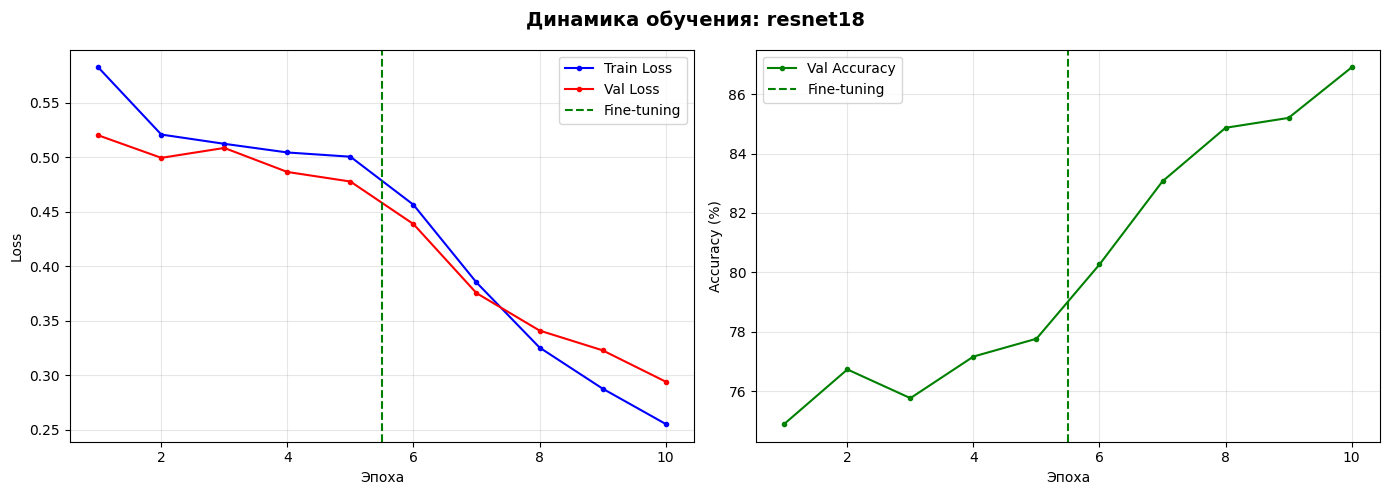


[Результаты] Метрики на тестовом наборе:
              precision    recall  f1-score   support

        fake       0.88      0.86      0.87      1500
        real       0.86      0.88      0.87      1500

    accuracy                           0.87      3000
   macro avg       0.87      0.87      0.87      3000
weighted avg       0.87      0.87      0.87      3000



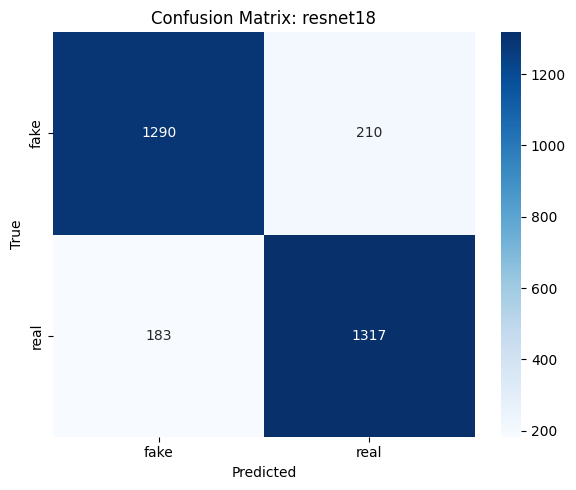


[Интерпретация] Генерация тепловых карт Grad-CAM...


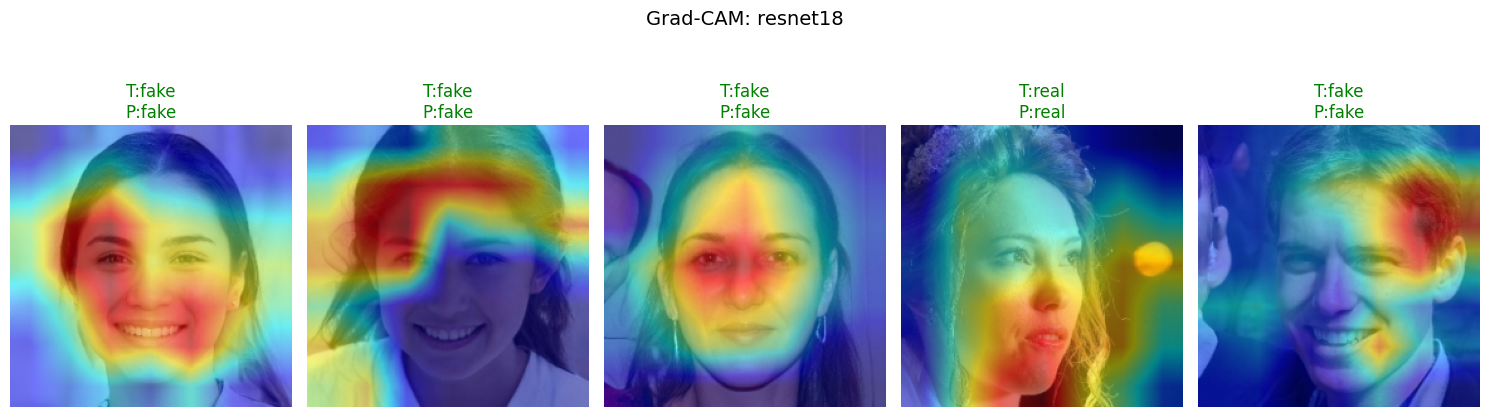


  ИТОГ: resnet18 | Accuracy: 86.90% | Время: 461.3с



In [32]:
# Эксперимент 1: ResNet18 (11.7M параметров)
print("="*60)
print("ЭКСПЕРИМЕНТ 1: ResNet18")
print("="*60)
print("ResNet18 — лёгкая архитектура с остаточными связями.")
print("Оптимальна для ограниченных датасетов и быстрого прототипирования.")
print()

results_resnet18 = execute_full_pipeline(
    model_name='resnet18',
    train_loader=train_loader,
    test_loader=test_loader,
    class_names=class_names,
    device=DEVICE,
    head_epochs=5,
    ft_epochs=5,
    head_lr=1e-3,
    ft_lr=1e-5
)

ЭКСПЕРИМЕНТ 2: EfficientNetB0
EfficientNetB0 — современная эффективная архитектура.
Использует compound scaling и SE-блоки.

  ЗАПУСК ЭКСПЕРИМЕНТА: EFFICIENTNET_B0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 145MB/s]


Модель efficientnet_b0 загружена. Всего параметров: 4,010,110

[Этап 1] Обучение головы модели (lr=0.001, epochs=5)
  [head] Обучаемые: 2,562 / 4,010,110 (0.1%)
  Epoch 1/5 | Train Loss: 0.5655 | Val Loss: 0.5066 | Val Acc: 76.0%
  Epoch 2/5 | Train Loss: 0.5046 | Val Loss: 0.4768 | Val Acc: 77.7%
  Epoch 3/5 | Train Loss: 0.4899 | Val Loss: 0.4634 | Val Acc: 78.6%
  Epoch 4/5 | Train Loss: 0.4865 | Val Loss: 0.4539 | Val Acc: 79.2%
  Epoch 5/5 | Train Loss: 0.4678 | Val Loss: 0.4497 | Val Acc: 79.1%

[Этап 2] Fine-tuning базовой сети (lr=1e-05, epochs=5)
  [finetune] Обучаемые: 3,158,302 / 4,010,110 (78.8%)
  Epoch 1/5 | Train Loss: 0.4512 | Val Loss: 0.4103 | Val Acc: 81.2%
  Epoch 2/5 | Train Loss: 0.4142 | Val Loss: 0.3842 | Val Acc: 82.8%
  Epoch 3/5 | Train Loss: 0.3808 | Val Loss: 0.3639 | Val Acc: 84.3%
  Epoch 4/5 | Train Loss: 0.3583 | Val Loss: 0.3389 | Val Acc: 85.7%
  Epoch 5/5 | Train Loss: 0.3367 | Val Loss: 0.3166 | Val Acc: 86.5%


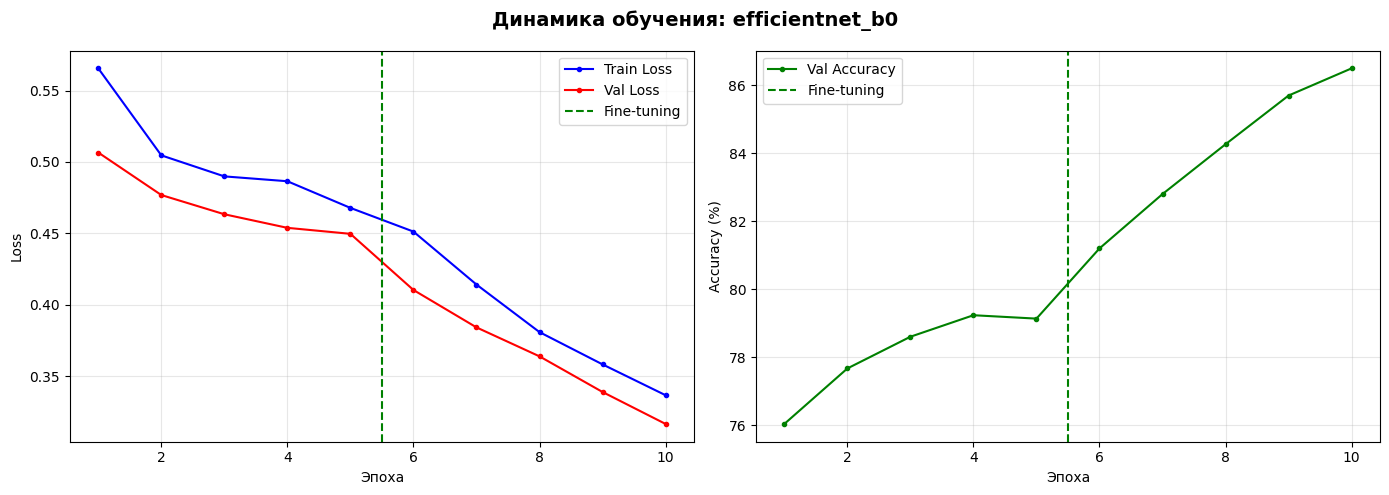


[Результаты] Метрики на тестовом наборе:
              precision    recall  f1-score   support

        fake       0.85      0.88      0.87      1500
        real       0.88      0.85      0.86      1500

    accuracy                           0.86      3000
   macro avg       0.87      0.86      0.86      3000
weighted avg       0.87      0.86      0.86      3000



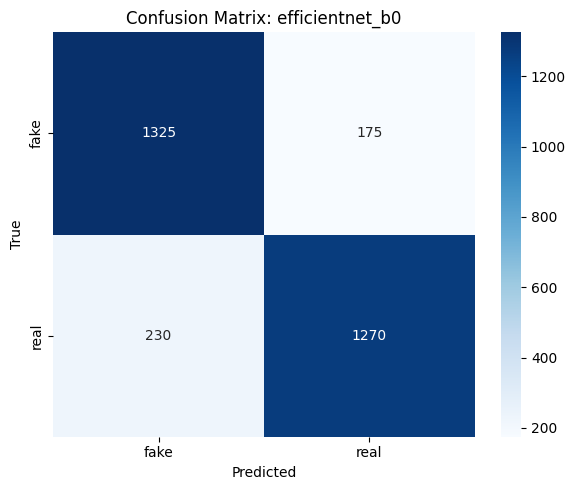


[Интерпретация] Генерация тепловых карт Grad-CAM...


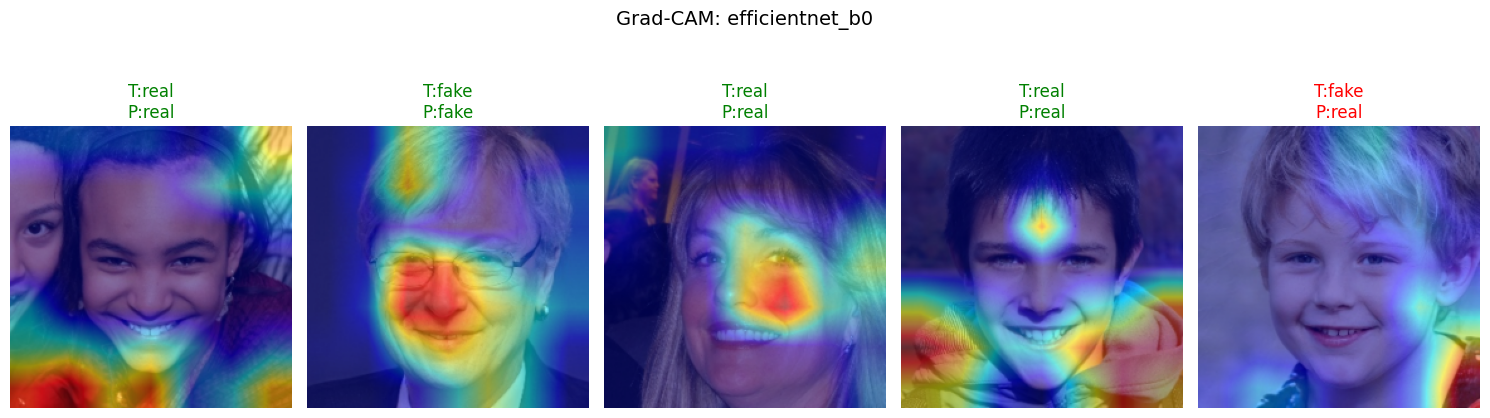


  ИТОГ: efficientnet_b0 | Accuracy: 86.50% | Время: 441.4с



In [33]:
# Эксперимент 2: EfficientNetB0 (5.3M параметров)
print("="*60)
print("ЭКСПЕРИМЕНТ 2: EfficientNetB0")
print("="*60)
print("EfficientNetB0 — современная эффективная архитектура.")
print("Использует compound scaling и SE-блоки.")
print()

results_effnet = execute_full_pipeline(
    model_name='efficientnet_b0',
    train_loader=train_loader,
    test_loader=test_loader,
    class_names=class_names,
    device=DEVICE,
    head_epochs=5,
    ft_epochs=5,
    head_lr=1e-3,
    ft_lr=1e-5
)

ЭКСПЕРИМЕНТ 3: MobileNetV2
MobileNetV2 — сверхкомпактная модель.
Использует depthwise separable convolutions.

  ЗАПУСК ЭКСПЕРИМЕНТА: MOBILENET_V2
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 184MB/s]

Модель mobilenet_v2 загружена. Всего параметров: 2,226,434

[Этап 1] Обучение головы модели (lr=0.001, epochs=5)
  [head] Обучаемые: 2,562 / 2,226,434 (0.1%)


  Epoch 1/5 | Train Loss: 0.5814 | Val Loss: 0.5143 | Val Acc: 74.8%
  Epoch 2/5 | Train Loss: 0.5230 | Val Loss: 0.5884 | Val Acc: 70.0%
  Epoch 3/5 | Train Loss: 0.5163 | Val Loss: 0.4862 | Val Acc: 75.3%
  Epoch 4/5 | Train Loss: 0.5156 | Val Loss: 0.4835 | Val Acc: 76.1%
  Epoch 5/5 | Train Loss: 0.5046 | Val Loss: 0.4728 | Val Acc: 76.8%

[Этап 2] Fine-tuning базовой сети (lr=1e-05, epochs=5)
  [finetune] Обучаемые: 1,208,642 / 2,226,434 (54.3%)
  Epoch 1/5 | Train Loss: 0.4725 | Val Loss: 0.4339 | Val Acc: 78.8%
  Epoch 2/5 | Train Loss: 0.4417 | Val Loss: 0.4056 | Val Acc: 80.7%
  Epoch 3/5 | Train Loss: 0.4183 | Val Loss: 0.3893 | Val Acc: 81.1%
  Epoch 4/5 | Train Loss: 0.3854 | Val Loss: 0.3717 | Val Acc: 81.9%
  Epoch 5/5 | Train Loss: 0.3719 | Val Loss: 0.3533 | Val Acc: 83.5%


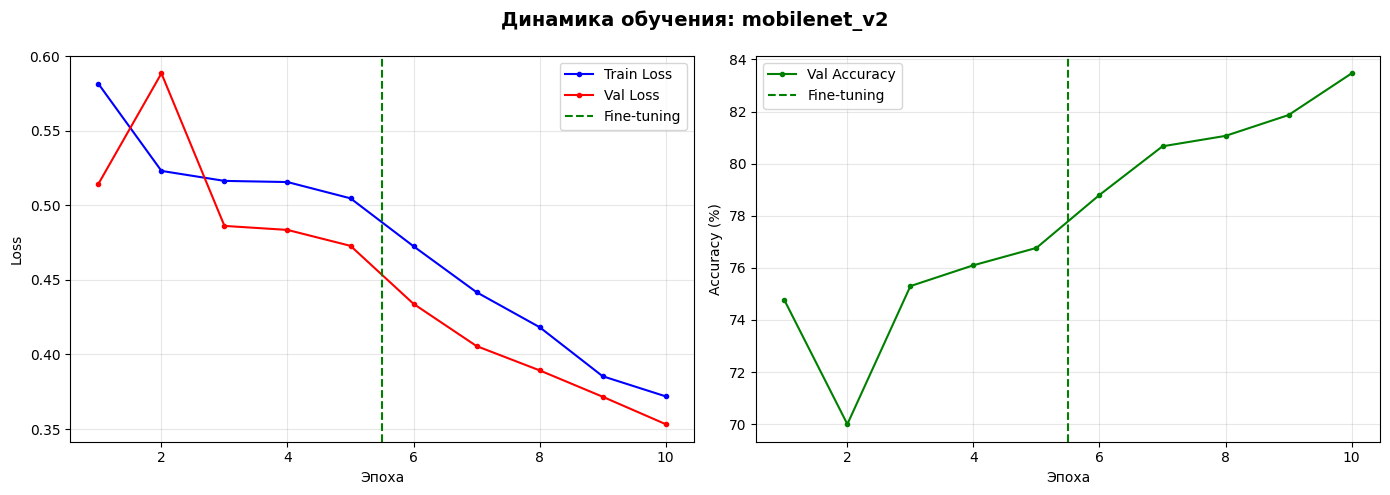


[Результаты] Метрики на тестовом наборе:
              precision    recall  f1-score   support

        fake       0.82      0.85      0.84      1500
        real       0.85      0.82      0.83      1500

    accuracy                           0.83      3000
   macro avg       0.84      0.83      0.83      3000
weighted avg       0.84      0.83      0.83      3000



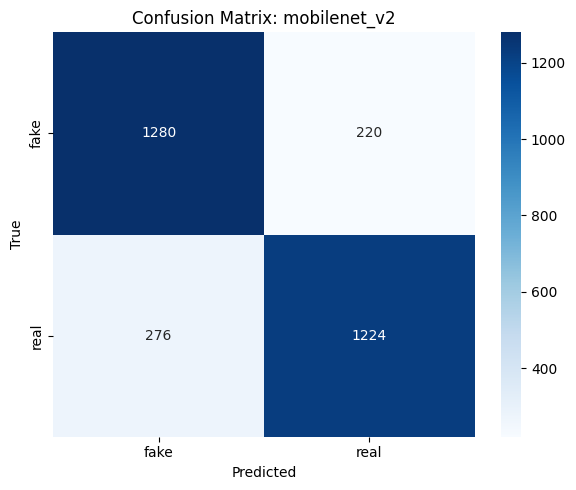


[Интерпретация] Генерация тепловых карт Grad-CAM...


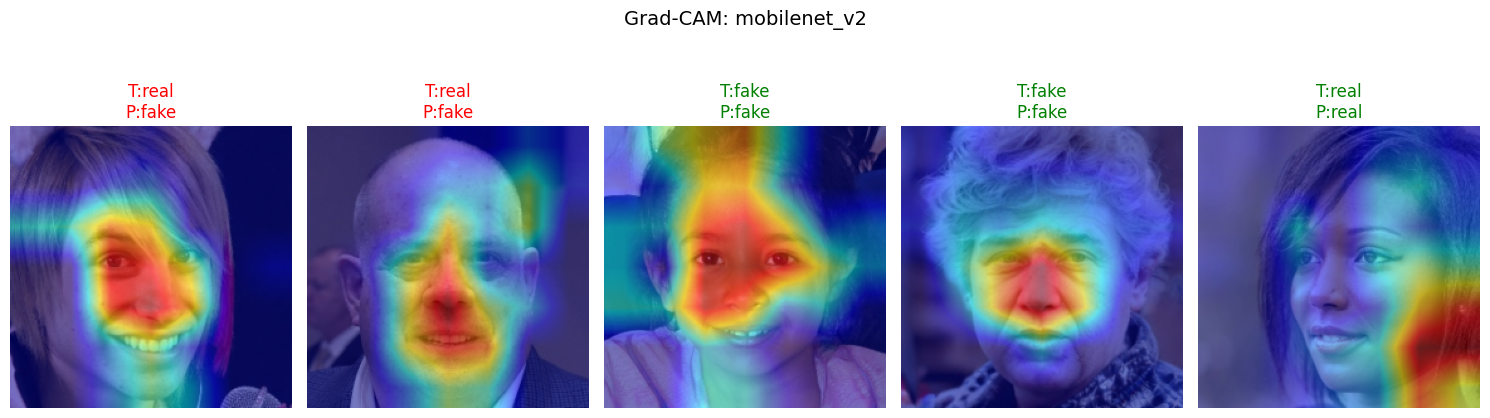


  ИТОГ: mobilenet_v2 | Accuracy: 83.47% | Время: 427.0с



In [34]:
# Эксперимент 3: MobileNetV2 (3.4M параметров)
print("="*60)
print("ЭКСПЕРИМЕНТ 3: MobileNetV2")
print("="*60)
print("MobileNetV2 — сверхкомпактная модель.")
print("Использует depthwise separable convolutions.")
print()

results_mobilenet = execute_full_pipeline(
    model_name='mobilenet_v2',
    train_loader=train_loader,
    test_loader=test_loader,
    class_names=class_names,
    device=DEVICE,
    head_epochs=5,
    ft_epochs=5,
    head_lr=1e-3,
    ft_lr=1e-5
)

In [35]:
import pandas as pd

# Сводная таблица результатов
print("\n" + "="*70)
print("СРАВНИТЕЛЬНЫЙ АНАЛИЗ АРХИТЕКТУР")
print("="*70)

results_list = [results_resnet18, results_effnet, results_mobilenet]

summary_data = {
    'Модель': [r['model_name'] for r in results_list],
    'Accuracy (%)': [f"{r['test_accuracy']:.2f}" for r in results_list],
    'Время обучения (с)': [f"{r['execution_time']:.1f}" for r in results_list],
    'Параметров': [
        f"{sum(p.numel() for p in r['model_object'].parameters()):,}"
        for r in results_list
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print("="*70)


СРАВНИТЕЛЬНЫЙ АНАЛИЗ АРХИТЕКТУР
         Модель Accuracy (%) Время обучения (с) Параметров
       resnet18        86.90              461.3 11,177,538
efficientnet_b0        86.50              441.4  4,010,110
   mobilenet_v2        83.47              427.0  2,226,434


In [36]:
# Собираем результаты всех экспериментов в один список

all_results = [
    results_resnet18,
    results_effnet,
    results_mobilenet
]

# Выбираем лучшую модель по accuracy (ключ test_accuracy)
best_result = max(all_results, key=lambda r: r['test_accuracy'])
best_model = best_result['model_object']  # Ключ model_object
best_name = best_result['model_name']

print(f"Лучшая модель: {best_name} (Accuracy: {best_result['test_accuracy']:.2f}%)")

# Определяем слои для визуализации (для выбранной архитектуры)
if best_name == 'resnet18':
    layers = {
        "Early (conv1)": best_model.conv1,
        "Middle (layer2)": best_model.layer2,
        "Deep (layer4)": best_model.layer4,
    }
elif best_name in ('efficientnet_b0', 'mobilenet_v2'):
    layers = {
        "Early (features[0])": best_model.features[0],
        "Middle (features[4])": best_model.features[4],
        "Deep (features[-1])": best_model.features[-1],
    }
else:
    raise ValueError(f"Визуализация не настроена для модели: {best_name}")

print(f"Слои для визуализации: {list(layers.keys())}")

Лучшая модель: resnet18 (Accuracy: 86.90%)
Слои для визуализации: ['Early (conv1)', 'Middle (layer2)', 'Deep (layer4)']


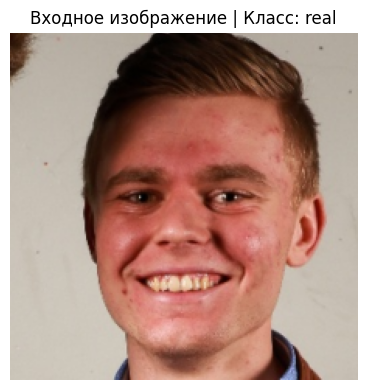

In [37]:
# Регистрация forward hooks для перехвата активаций
feature_maps = {}

def get_features(name):
    def hook(module, input, output):
        feature_maps[name] = output.detach()
    return hook

hooks = []
for name, layer in layers.items():
    hooks.append(layer.register_forward_hook(get_features(name)))

# Выбор случайного изображения из тестового набора
idx = random.randint(0, len(test_dataset) - 1)
img, label = test_dataset[idx]
input_tensor = img.unsqueeze(0).to(DEVICE)

# Прямой проход для сбора feature maps
best_model.eval()
with torch.no_grad():
    _ = best_model(input_tensor)

# Визуализация входного изображения
img_display = denormalize(img).permute(1, 2, 0).numpy()
plt.figure(figsize=(4, 4))
plt.imshow(img_display)
plt.title(f"Входное изображение | Класс: {class_names[label]}")
plt.axis("off")
plt.tight_layout()
plt.show()

# Очистка hooks после сбора данных
for h in hooks:
    h.remove()

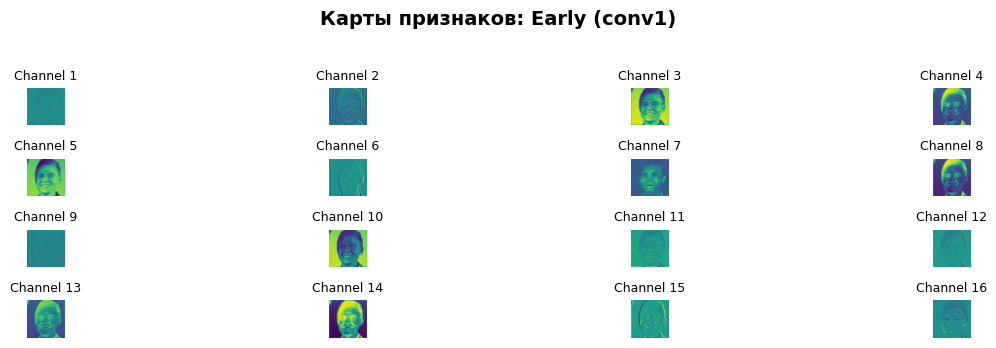

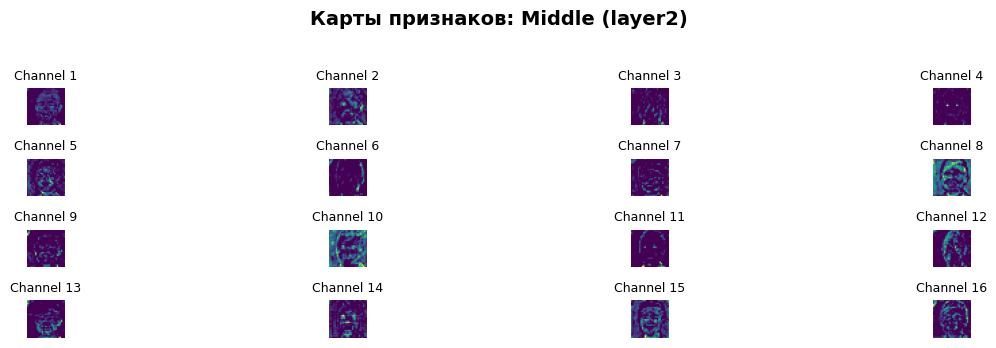

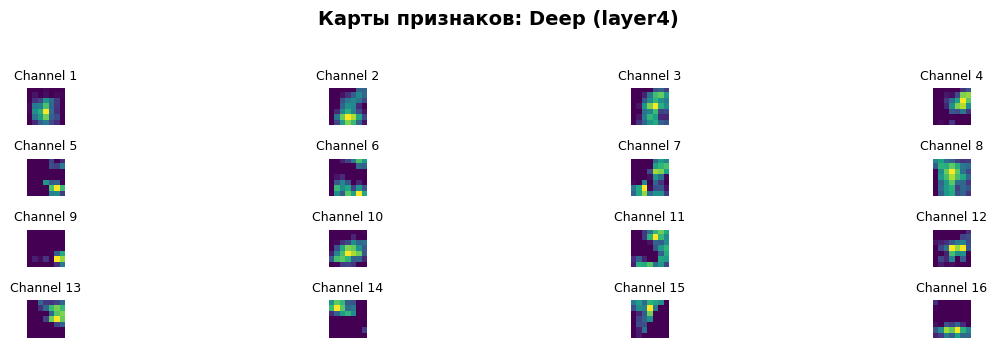

In [38]:
# Функция визуализации карт признаков для каждого слоя
def plot_feature_maps(activations, layer_name, max_ch=16):
    activations = activations.squeeze(0).cpu()
    n_channels = min(max_ch, activations.shape[0])

    fig, axes = plt.subplots(4, 4, figsize=(14, 3.5))
    fig.suptitle(f"Карты признаков: {layer_name}", fontsize=14, fontweight='bold')

    for i, ax in enumerate(axes.flat):
        if i < n_channels:
            ax.imshow(activations[i].numpy(), cmap='viridis')
            ax.set_title(f'Channel {i+1}', fontsize=9)
        ax.axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Построение визуализации для каждого выбранного слоя
for name, tensor in feature_maps.items():
    plot_feature_maps(tensor, name)

## 11. Сохранение результатов

Модель и метаданные сохранены: /content/best_model_resnet18.pth


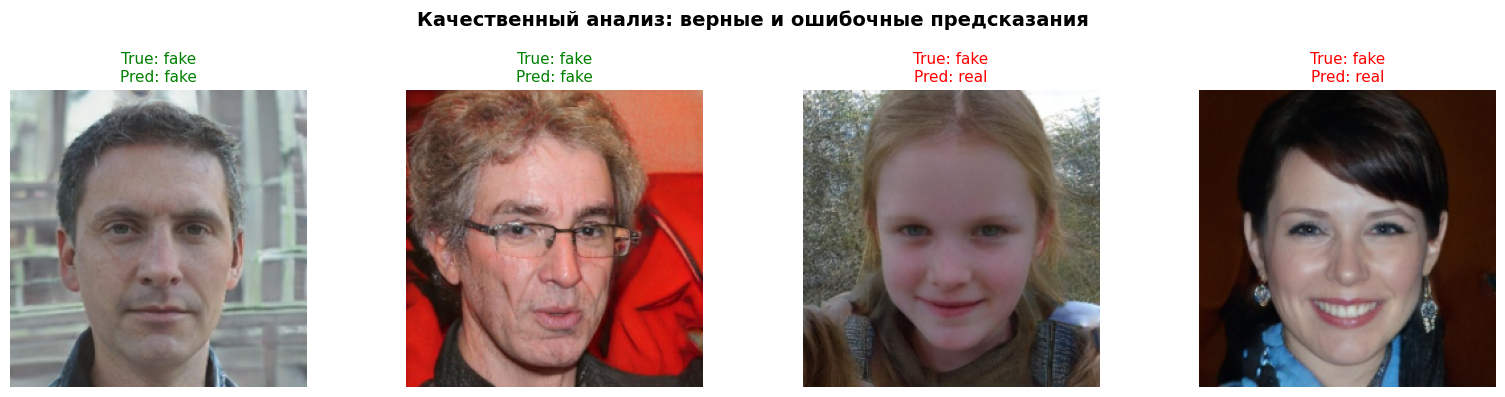

In [40]:
# Сохранение лучшей модели и метаданных
checkpoint = {
    'model_name': best_name,
    'state_dict': best_model.state_dict(),
    'accuracy': best_result['test_accuracy'],
    'class_names': class_names,
    'img_size': IMG_SIZE
}
save_path = f'/content/best_model_{best_name}.pth'
torch.save(checkpoint, save_path)
print(f"Модель и метаданные сохранены: {save_path}")

# Качественный анализ: собираем 2 верных и 2 ошибочных предсказания
best_model.eval()
correct_preds = []
wrong_preds = []

with torch.no_grad():
    for img, label in test_dataset:
        input_tensor = img.unsqueeze(0).to(DEVICE)
        output = best_model(input_tensor)
        _, predicted = torch.max(output, 1)
        pred_label = predicted.item()

        if pred_label == label and len(correct_preds) < 2:
            correct_preds.append((img, label, pred_label))
        elif pred_label != label and len(wrong_preds) < 2:
            wrong_preds.append((img, label, pred_label))

        if len(correct_preds) == 2 and len(wrong_preds) == 2:
            break

# Визуализация примеров
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Качественный анализ: верные и ошибочные предсказания', fontsize=14, fontweight='bold')

samples = correct_preds + wrong_preds
for i, (img, true, pred) in enumerate(samples):
    img_np = denormalize(img).permute(1, 2, 0).numpy()
    axes[i].imshow(img_np)
    color = 'green' if true == pred else 'red'
    axes[i].set_title(f"True: {class_names[true]}\nPred: {class_names[pred]}",
                      fontsize=11, color=color)
    axes[i].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()